**Variational Autoencoder (VAE) + Latent Space Visualization**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 352kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.34MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.55MB/s]


In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        x = x.view(-1, 784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [3]:
def vae_loss(recon_x, x, mu, logvar):
    x = x.view(-1, 784)

    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

In [4]:
model = VAE(latent_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader.dataset):.4f}")

Epoch [1/10], Loss: 189.6599
Epoch [2/10], Loss: 168.0806
Epoch [3/10], Loss: 163.8678
Epoch [4/10], Loss: 161.6087
Epoch [5/10], Loss: 159.9289
Epoch [6/10], Loss: 158.6480
Epoch [7/10], Loss: 157.5044
Epoch [8/10], Loss: 156.5282
Epoch [9/10], Loss: 155.6440
Epoch [10/10], Loss: 154.8951


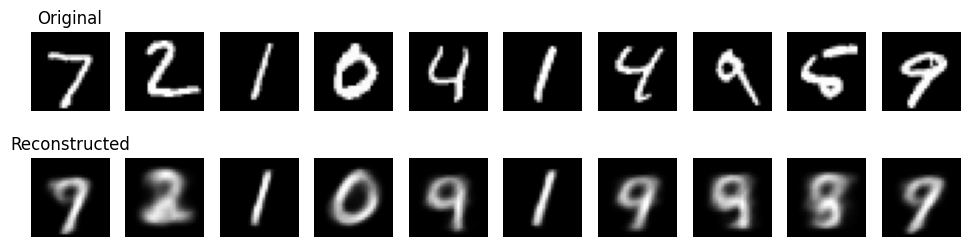

In [5]:
model.eval()

x, _ = next(iter(test_loader))
x = x.to(device)

with torch.no_grad():
    recon, _, _ = model(x)

x = x.cpu().view(-1, 28, 28)
recon = recon.cpu().view(-1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(12, 3))

for i in range(10):
    axes[0, i].imshow(x[i], cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(recon[i], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.show()

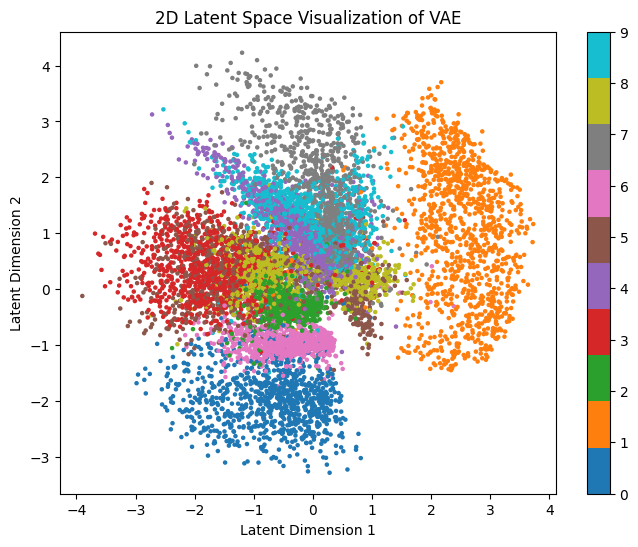

In [6]:
model.eval()

z_points = []
labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        x = x.view(-1, 784)

        mu, logvar = model.encode(x)

        z_points.append(mu.cpu())
        labels.append(y)

z_points = torch.cat(z_points)
labels = torch.cat(labels)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    z_points[:, 0],
    z_points[:, 1],
    c=labels,
    cmap="tab10",
    s=5
)
plt.colorbar(scatter)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D Latent Space Visualization of VAE")
plt.show()

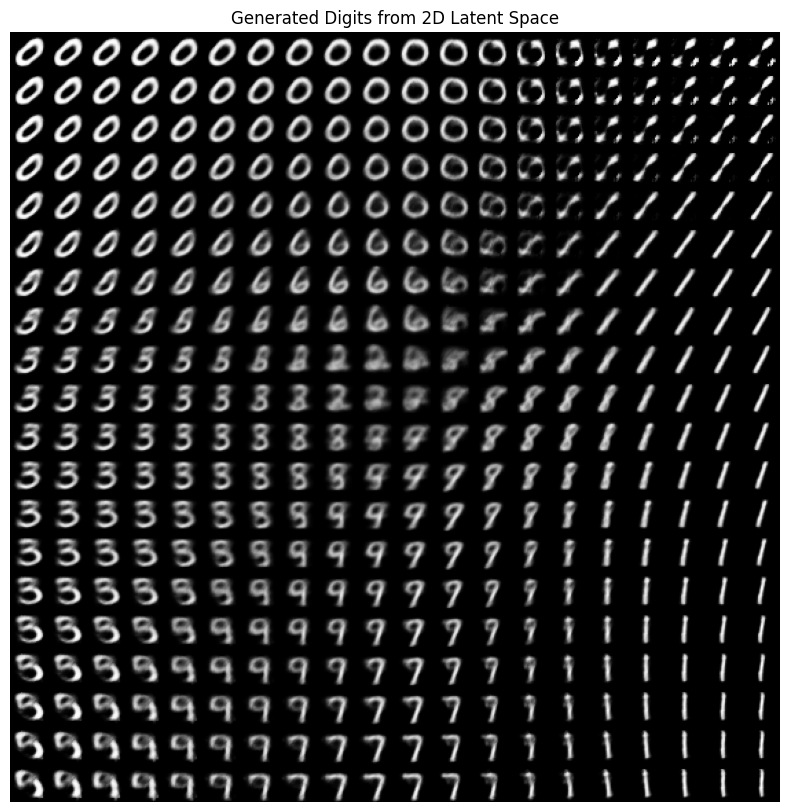

In [7]:
grid_x = torch.linspace(-3, 3, 20)
grid_y = torch.linspace(-3, 3, 20)

figure = torch.zeros(28 * 20, 28 * 20)

model.eval()

with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], device=device)
            generated = model.decode(z).cpu().view(28, 28)
            figure[i*28:(i+1)*28, j*28:(j+1)*28] = generated

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.title("Generated Digits from 2D Latent Space")
plt.show()